In [1]:
!pip install autograd
!pip install pennylane
!pip install qiskit
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install pylatexenc
!pip install scipy
!pip install scikit-optimize
!pip install pennylane-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 

In [2]:
import pennylane as qml

from qiskit import QuantumCircuit
from qiskit import transpile, assemble
from qiskit_ibm_runtime import SamplerV2
import numpy as np
import matplotlib . pyplot as plt
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit.qpy import load
from qiskit import qpy
import io
import base64
import pylatexenc
import random
from scipy.optimize import minimize
import math
import torch
import torch.optim as optim
dev = qml.device("default.qubit", wires=3)


In [15]:
#States
Q3_ghz_state = np.array([1/np.sqrt(2), 0, 0, 0, 0, 0, 0, 1/np.sqrt(2)])
w3_state = np.array([0, 1/np.sqrt(3), 1/np.sqrt(3), 0, 1/np.sqrt(3), 0, 0, 0])

In [4]:
@qml.qnode(dev)
def psi(theta):
  # Apply RZ gates
  qml.RZ(theta[0], wires=0)  # RZ[\[Theta]_a] -> qubit 1
  qml.RZ(theta[1], wires=1)  # RZ[\[Theta]_b] -> qubit 2
  qml.RZ(theta[2], wires=2)  # RZ[\[Theta]_c] -> qubit 3

  # Apply RY gates
  qml.RY(theta[3], wires=0)  # RY[\[Theta]_d] -> qubit 1
  qml.RY(theta[4], wires=1)  # RY[\[Theta]_e] -> qubit 2
  qml.RY(theta[5], wires=2)  # RY[\[Theta]_f] -> qubit 3

  # Apply more RZ gates
  qml.RZ(theta[6], wires=0)  # RZ[\[Theta]_g] -> qubit 1
  qml.RZ(theta[7], wires=1)  # RZ[\[Theta]_h] -> qubit 2
  qml.RZ(theta[8], wires=2)  # RZ[\[Theta]_i] -> qubit 3

  # Apply CNOT gates
  qml.CNOT(wires=[0, 1])  # CNOT -> qubit 1 (control) and qubit 2 (target)
  qml.CNOT(wires=[1, 2])  # CNOT -> qubit 2 (control) and qubit 3 (target)
  qml.CNOT(wires=[2, 0])  # CNOT -> qubit 3 (control) and qubit 1 (target)

  # Apply more RZ gates
  qml.RZ(theta[9], wires=0)  # RZ[\[Theta]_j] -> qubit 1
  qml.RZ(theta[10], wires=1)  # RZ[\[Theta]_k] -> qubit 2
  qml.RZ(theta[11], wires=2)  # RZ[\[Theta]_l] -> qubit 3

  # Apply more RY gates
  qml.RY(theta[12], wires=0)  # RY[\[Theta]_m] -> qubit 1
  qml.RY(theta[13], wires=1)  # RY[\[Theta]_n] -> qubit 2
  qml.RY(theta[14], wires=2)  # RY[\[Theta]_o] -> qubit 3

  # Apply more RZ gates
  qml.RZ(theta[15], wires=0)  # RZ[\[Theta]_p] -> qubit 1
  qml.RZ(theta[16], wires=1)  # RZ[\[Theta]_q] -> qubit 2
  qml.RZ(theta[17], wires=2)  # RZ[\[Theta]_r] -> qubit 3

  # Apply more CNOT gates
  qml.CNOT(wires=[0, 2])  # CNOT -> qubit 1 (control) and qubit 3 (target)
  qml.CNOT(wires=[1, 0])  # CNOT -> qubit 2 (control) and qubit 1 (target)
  qml.CNOT(wires=[2, 1])  # CNOT -> qubit 3 (control) and qubit 2 (target)

  # Apply RX gate
  qml.RY(theta[18], wires=0)  # RX[\[Theta]_s] -> qubit 1

  # Apply more RY and RZ gates
  qml.RY(theta[19], wires=0)  # RY[\[Theta]_t] -> qubit 1
  qml.RZ(theta[20], wires=1)  # RZ[\[Theta]_u] -> qubit 2
  qml.RZ(theta[21], wires=2)  # RZ[\[Theta]_v] -> qubit 3
  qml.RZ(theta[22], wires=0)  # RZ[\[Theta]_w] -> qubit 1
  qml.RY(theta[23], wires=1)  # RY[\[Theta]_x] -> qubit 2
  qml.RY(theta[24], wires=2)  # RY[\[Theta]_y] -> qubit 3
  qml.RZ(theta[25], wires=1)  # RZ[\[Theta]_z] -> qubit 2
  qml.RZ(theta[26], wires=2)    # RZ[\[Theta]] -> qubit 3

  # Apply CNOT gates again
  qml.CNOT(wires=[0, 1])  # CNOT -> qubit 1 (control) and qubit 2 (target)
  qml.CNOT(wires=[1, 2])  # CNOT -> qubit 2 (control) and qubit 3 (target)
  qml.CNOT(wires=[2, 0])  # CNOT -> qubit 3 (control) and qubit 1 (target)

  return qml.state()

In [42]:
def cost_function(theta):
    # Generate quantum states
    #psi_state = qml.math.dm_from_state_vector(psi(theta))
    psi_state = psi(theta)
    ghz_state = w3_state
    #ghz_state = qml.math.dm_from_state_vector(ghz_state)

    # Compute the inner product
    fidelity = np.abs(np.real(np.vdot(np.conj(ghz_state), psi_state)))
    #fidelity = qml.math.fidelity(ghz_state, psi_state)

    # Return the real part of the inner product
    cost = 1 - (fidelity)

    return cost

In [6]:
import numpy as np

# Generate a list of 10 random numbers between 0 and 2pi
theta = np.random.uniform(-(np.pi), np.pi, 27)
theta = qml.numpy.array(theta)
theta

tensor([-2.00238486, -2.6304719 ,  1.24136396,  0.65962472, -0.5710178 ,
         2.65463079,  2.44535436,  2.36430381,  0.99405596,  1.79000486,
        -0.2684343 ,  2.80169198,  0.3423623 , -0.94276125,  1.12807691,
         2.68409786, -1.25310826,  0.22638697, -3.09478112, -0.29454457,
         0.21000328,  1.24094213,  1.0380681 ,  1.85004411,  0.86149238,
        -1.99691828,  0.13424444], requires_grad=True)

In [7]:
def grad_compute(theta):
  theta = qml.numpy.array(theta)
  gradient = qml.grad(cost_function)
  grad = gradient((theta))
  return grad

In [ ]:
import json

x = grad_compute(theta)
x = x.tolist()
result_path = '/content/drive/MyDrive/Colab Notebooks/grad.json'
with open(result_path, 'w') as f:
    json.dump(x, f)

In [8]:
def hessian_compute(theta):
  hessianM = qml.jacobian(grad_compute)
  hess = hessianM(theta)
  return hess

In [9]:
import numpy as np

def wrap_to_pi(theta):
    """Wraps theta values to the range [-pi, pi]."""
    return (theta + np.pi) % (2 * np.pi) - np.pi

def update_step(theta, K, alpha, beta, delta):
    """
    Perform one step of the Iterative Preconditioned Gradient Descent (IPGD) algorithm.

    Args:
    - params (np.array): Current parameters of the quantum circuit.
    - gradient (np.array): Gradient of the cost function with respect to params.
    - hessian (np.array): Hessian matrix (second derivative of the cost function).
    - K (np.array): Preconditioner matrix.
    - alpha (float): Step size for parameter updates (default 0.01).
    - beta (float): Regularization parameter for the preconditioner update (default 0.1).

    Returns:
    - params_new (np.array): Updated parameters.
    - K_new (np.array): Updated preconditioner matrix.
    """
    gradient = grad_compute(theta)
    hessian = hessian_compute(theta)
    hessian = hessian + 1e-23 * np.eye(len(theta))
    # Identity matrix (for regularization of the Hessian)
    I = np.eye(len(theta))  # Identity matrix of the same size as the parameters

    # Step 1: Update parameters using the gradient and preconditioner
    theta_new = theta - delta * np.dot(K, gradient)
    theta_new = wrap_to_pi(theta_new)

    # Step 2: Update the preconditioner using the Hessian and regularization term
    K_new = K - alpha * (np.dot((hessian + beta * I), K) - I)

    return theta_new, K_new

In [10]:
import numpy as np

def iterativePreconditionedGD(initial_theta, num_iterations=50, delta=0.999, zeta=0.01):

    H = hessian_compute(initial_theta)
    eigenvalues = np.linalg.eigvals(H)
    max_eigenvalue = np.max(eigenvalues)
    min_eigenvalue = np.min(eigenvalues)

    grad_e = grad_compute(initial_theta)
    norm = np.linalg.norm(grad_e)

    beta = zeta + (min_eigenvalue * -1)
    o_delta = norm/(max_eigenvalue + beta)
    alpha = (1/((max_eigenvalue) + beta)) - zeta

    cost_history = []
    cost_history.append(cost_function(initial_theta))


    theta = initial_theta
    K = np.random.randn(len(theta), len(theta))

    for i in range(num_iterations):

        theta, K = update_step(theta, K, alpha, beta, delta)
        cost = cost_function(theta)
        cost_history.append(cost)

    data = [theta, cost_history]
    return data


In [ ]:


# For CPU-based device
dev_cpu = qml.device("default.qubit", wires=3)
print(dev_cpu)

<default.qubit device (wires=3) at 0x7b80505eb610>


In [49]:
import json

def IPG_analyzer():
  for i in range(1):
    avg_tracker = []
    best_tracker = []
    Parameters = {"delta": [0.5], "zeta":[0.1]}
    theta = np.random.uniform(-(np.pi), np.pi, 27)
    theta = qml.numpy.array(theta)
    for delta in Parameters["delta"]:
      for zeta in Parameters["zeta"]:
          current_low = 1
          index = -1
          cost_tracker = []
          for i in range(2):
            results = iterativePreconditionedGD(theta, 100, delta, zeta)
            lowest_cost = np.min(results[1])
            optimized_theta = results[0]
            #print(f"Lowest Cost: {lowest_cost}")
            if lowest_cost < current_low:
              current_low = lowest_cost
              index = i
              best_theta = optimized_theta
            cost_tracker.append(results[1])
          cost_tracker = np.array(cost_tracker)
          avg_history = np.mean(cost_tracker, axis=0)

          avg_tracker.append(avg_history)
          best_tracker.append(cost_tracker[index])

  avg = np.mean(avg_tracker, axis=0)
  best = np.mean(best_tracker, axis=0)
  return best, avg, best_theta

IPGbest, IPGavg, IPGOptTheta = IPG_analyzer()

IPGavg = IPGavg.tolist()
IPGbest = IPGbest.tolist()
IPGOptTheta = IPGOptTheta.tolist()
IPGbest_path = '/content/drive/MyDrive/Colab Notebooks/IPGbest.json'
IPGavg_path = '/content/drive/MyDrive/Colab Notebooks/IPGavg.json'
IPGtheta_path = '/content/drive/MyDrive/Colab Notebooks/IPGtheta.json'
with open(IPGbest_path, 'w') as f:
    json.dump(IPGbest, f)
with open(IPGavg_path, 'w') as g:
    json.dump(IPGavg, g)
with open(IPGtheta_path, 'w') as j:
    json.dump(IPGOptTheta, j)

In [21]:
def gradient_descent_update(theta, alpha=0.05):
  gradient = grad_compute(theta)
  theta_new = theta - alpha*(gradient)
  theta_new = np.mod(theta_new, 2 * np.pi)

  return theta_new

In [22]:
def GD(initial_theta, num_iter, alpha=0.05):
  theta = initial_theta
  cost_history = []
  cost_history.append(cost_function(initial_theta))
  for i in range(num_iter):
    theta = gradient_descent_update(theta, alpha)
    cost = cost_function(theta)
    cost_history.append(cost)

  data = [theta, cost_history]
  return data

In [23]:
def GD_analyzer():
  current_low = 1
  index = -1
  cost_tracker = []
  for i in range(100):
    theta = np.random.uniform(-(np.pi), np.pi, 27)
    theta = qml.numpy.array(theta)
    results = GD(theta, 100)
    optimized_theta = results[0]
    lowest_cost = np.min(results[1])
    #print(f"Lowest Cost: {lowest_cost}")
    if lowest_cost < current_low:
      current_low = lowest_cost
      index = i
      best_theta = optimized_theta
    cost_tracker.append(results[1])

  GD_cost_tracker = np.array(cost_tracker)
  GD_avg_history = np.mean(cost_tracker, axis=0)
  GD_best_history = cost_tracker[index]

  return GD_best_history, GD_avg_history, best_theta, current_low

GDbest, GDavg, GDOptTheta, GDCost = GD_analyzer()
import json

GDavg = GDavg.tolist()
GDOptTheta = GDOptTheta.tolist()
GDbest_path = '/content/drive/MyDrive/Colab Notebooks/GDbest.json'
GDavg_path = '/content/drive/MyDrive/Colab Notebooks/GDavg.json'
GDlowest_path = '/content/drive/MyDrive/Colab Notebooks/GDlowest.json'
GDtheta_path = '/content/drive/MyDrive/Colab Notebooks/GDtheta.json'
with open(GDbest_path, 'w') as f:
    json.dump(GDbest, f)
with open(GDavg_path, 'w') as g:
    json.dump(GDavg, g)
with open(GDlowest_path, 'w') as h:
    json.dump(GDCost, h)
with open(GDtheta_path, 'w') as j:
    json.dump(GDOptTheta, j)

In [24]:
def AdamUpdate(theta, m_t0, v_t0, i, alpha=0.1, beta1=0.9, beta2=0.999, epsilon=1e-5):
  m_t1 = beta1 * m_t0 + (1 - beta1) * grad_compute(theta)
  v_t1 = beta2 * v_t0 + (1 - beta2) * np.square(grad_compute(theta))

  m = (m_t1)/(1-beta1**i)
  v = (v_t1)/(1-beta2**i)

  theta_new = theta - (alpha * m) / (np.sqrt(v) + epsilon)

  return theta_new, m_t1, v_t1

In [25]:
def Adam(initial_theta, num_iter, alpha=0.01, beta1=0.9, beta2=0.999, epsilon=1e-5):
  m_t0 = 0
  v_t0 = 0
  theta = initial_theta
  cost_history = []
  cost_history.append(cost_function(initial_theta))

  for i in range(1, num_iter + 1):
    theta, m_t0, v_t0 = AdamUpdate(theta, m_t0, v_t0, i)
    cost = cost_function(theta)
    cost_history.append(cost)

  data = [theta, cost_history]
  return data

In [26]:
def Adam_analyzer():
  current_low = 1
  index = -1
  cost_tracker = []
  for i in range(60):
    theta = np.random.uniform(-(np.pi), np.pi, 27)
    theta = qml.numpy.array(theta)
    results = Adam(theta, 100)
    optimized_theta = results[0]
    lowest_cost = np.min(results[1])
    #print(f"Lowest Cost: {lowest_cost}")
    if lowest_cost < current_low:
      current_low = lowest_cost
      index = i
      best_theta = optimized_theta
    cost_tracker.append(results[1])

  Adam_cost_tracker = np.array(cost_tracker)
  Adam_avg_history = np.mean(cost_tracker, axis=0)
  Adam_best_history = cost_tracker[index]

  return Adam_best_history, Adam_avg_history, best_theta, current_low

Adambest, Adamavg, AdamOptTheta, AdamCost = GD_analyzer()
Adamavg = Adamavg.tolist()
AdamOptTheta = AdamOptTheta.tolist()
Adambest_path = '/content/drive/MyDrive/Colab Notebooks/Adambest.json'
Adamavg_path = '/content/drive/MyDrive/Colab Notebooks/Adamavg.json'
Adamlowest_path = '/content/drive/MyDrive/Colab Notebooks/Adamlowest.json'
Adamtheta_path = '/content/drive/MyDrive/Colab Notebooks/Adamtheta.json'
with open(Adambest_path, 'w') as f:
    json.dump(Adambest, f)
with open(Adamavg_path, 'w') as g:
    json.dump(Adamavg, g)
with open(Adamlowest_path, 'w') as h:
    json.dump(AdamCost, h)
with open(Adamtheta_path, 'w') as j:
    json.dump(AdamOptTheta, j)

In [16]:
import numpy as np
import pennylane as qml

# Backtracking line search (Armijo condition)
def backtracking_line_search(cost_function, grad, theta, search_dir, alpha=1.0, beta=0.5, c=1e-5):
    """
    Perform backtracking line search to find a step size that satisfies the Armijo condition.

    Parameters:
        cost_function: The objective function.
        grad: Gradient at the current point.
        theta: Current parameters.
        search_dir: Search direction.
        alpha: Initial step size.
        beta: Reduction factor for step size.
        c: Armijo condition constant.

    Returns:
        alpha: Step size that satisfies the Armijo condition.
    """
    while cost_function(theta + alpha * search_dir) > cost_function(theta) + c * alpha * np.dot(grad, search_dir):
        alpha *= beta
    return alpha

# L-BFGS implementation
def lbfgs_optimize(cost_function, grad_compute, theta_init, m=10, max_iter=60, tol=1e-6):
    """
    L-BFGS optimization algorithm.

    Parameters:
        cost_function: The objective function to minimize.
        grad_compute: Function to compute the gradient.
        theta_init: Initial parameter vector.
        m: Memory size (number of past updates to store).
        max_iter: Maximum number of iterations.
        tol: Convergence tolerance.

    Returns:
        theta: Optimized parameters.
        cost_history: List of cost values at each iteration.
    """
    theta = theta_init
    grad = grad_compute(theta)
    cost_history = [cost_function(theta)]

    # Storage for past updates
    s_list = []  # Parameter differences
    y_list = []  # Gradient differences
    rho_list = []  # Rho values for scaling

    for k in range(max_iter):
        #print(f"Iteration {k}, Cost: {cost_history[-1]}")

        # Check for convergence
        if np.linalg.norm(grad) < tol:
            print("Converged!")
            break

        # Compute search direction using two-loop recursion
        q = grad.copy()
        alpha_list = []
        for i in range(len(s_list) - 1, -1, -1):
            alpha = rho_list[i] * np.dot(s_list[i], q)
            alpha_list.append(alpha)
            q -= alpha * y_list[i]

        # Scale initial Hessian approximation
        if len(s_list) > 0:
            gamma = np.dot(s_list[-1], y_list[-1]) / (np.dot(y_list[-1], y_list[-1]) + 1e-8)
            r = gamma * q
        else:
            r = q

        for i in range(len(s_list)):
            beta = rho_list[i] * np.dot(y_list[i], r)
            r += s_list[i] * (alpha_list[len(s_list) - 1 - i] - beta)

        search_dir = -r

        # Perform backtracking line search
        alpha = backtracking_line_search(cost_function, grad, theta, search_dir)
        theta_new = theta + alpha * search_dir
        grad_new = grad_compute(theta_new)

        # Update history
        s = theta_new - theta
        y = grad_new - grad
        rho = 1.0 / (np.dot(y, s) + 1e-8)

        s_list.append(s)
        y_list.append(y)
        rho_list.append(rho)

        # Keep only the last m updates
        if len(s_list) > m:
            s_list.pop(0)
            y_list.pop(0)
            rho_list.pop(0)

        # Update for next iteration
        theta = theta_new
        grad = grad_new
        cost_history.append(cost_function(theta))

    return theta, cost_history

In [27]:
def lbfgs_analyzer():
  current_low = 1
  index = -1
  cost_tracker = []
  for i in range(10):
    theta = np.random.uniform(-(np.pi), np.pi, 27)
    theta = qml.numpy.array(theta)
    results = lbfgs_optimize(cost_function, grad_compute, theta)
    optimized_theta = results[0]
    lowest_cost = np.min(results[1])
    if lowest_cost < current_low:
      current_low = lowest_cost
      index = i
      best_theta = optimized_theta
    cost_tracker.append(results[1])

  lbfgs_cost_tracker = np.array(cost_tracker)
  lbfgs_avg_history = np.mean(cost_tracker, axis=0)
  lbfgs_best_history = cost_tracker[index]

  return lbfgs_best_history, lbfgs_avg_history, best_theta, current_low

lbfgsbest, lbfgsavg, lbfgsOptTheta, lbfgsCost = lbfgs_analyzer()

lbfgsavg = lbfgsavg.tolist()
lbfgsOptTheta = lbfgsOptTheta.tolist()
lbfgsbest_path = '/content/drive/MyDrive/Colab Notebooks/lbfgsbest.json'
lbfgsavg_path = '/content/drive/MyDrive/Colab Notebooks/lbfgsavg.json'
lbfgslowest_path = '/content/drive/MyDrive/Colab Notebooks/lbfgslowest.json'
lbfgstheta_path = '/content/drive/MyDrive/Colab Notebooks/lbfgstheta.json'
with open(lbfgsbest_path, 'w') as f:
    json.dump(lbfgsbest, f)
with open(lbfgsavg_path, 'w') as g:
    json.dump(lbfgsavg, g)
with open(lbfgslowest_path, 'w') as h:
    json.dump(lbfgsCost, h)
with open(lbfgstheta_path, 'w') as j:
    json.dump(lbfgsOptTheta, j)

In [28]:
from qiskit_ibm_runtime import SamplerV2, QiskitRuntimeService

In [30]:
theta = [-1.83988, -1.78455, 2.6754, -0.480997, -2.01687, 0.363118,
-0.951484, -2.96058, -0.469762, -1.42625, -2.98488, 0.811209,
-4.75918, 1.24889, -1.82879, 0.496782, -0.584122, 3.49375, 0.679085,
-0.286999, 2.45711, 0.615823, 0.106425, 0.870678, 1.22088, -0.60174,
-1.76332]

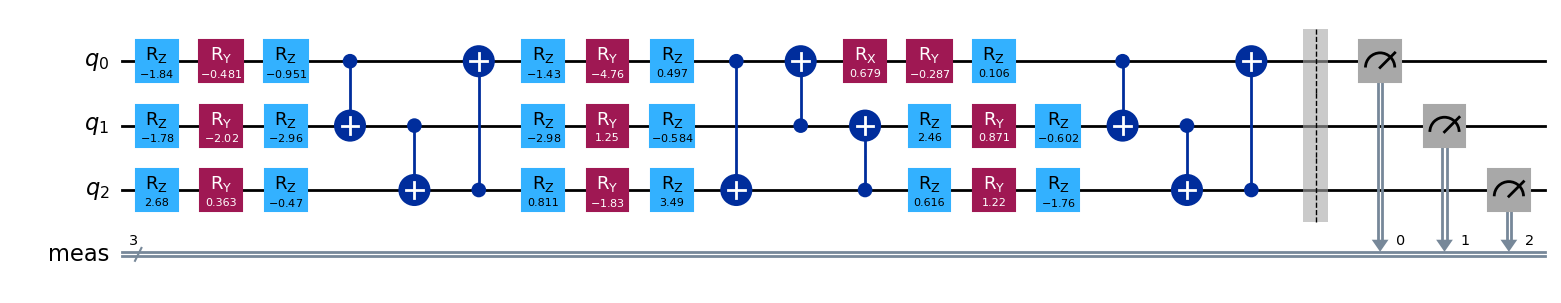

In [31]:
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import ParameterVector

# Create a quantum register with 3 qubits
qreg = QuantumRegister(3, 'q')
circuit = QuantumCircuit(qreg)

# Apply RZ gates
circuit.rz(theta[0], 0)
circuit.rz(theta[1], 1)
circuit.rz(theta[2], 2)

# Apply RY gates
circuit.ry(theta[3], 0)
circuit.ry(theta[4], 1)
circuit.ry(theta[5], 2)

# Apply more RZ gates
circuit.rz(theta[6], 0)
circuit.rz(theta[7], 1)
circuit.rz(theta[8], 2)

# Apply CNOT gates
circuit.cx(0, 1)
circuit.cx(1, 2)
circuit.cx(2, 0)

# Apply more RZ gates
circuit.rz(theta[9], 0)
circuit.rz(theta[10], 1)
circuit.rz(theta[11], 2)

# Apply more RY gates
circuit.ry(theta[12], 0)
circuit.ry(theta[13], 1)
circuit.ry(theta[14], 2)

# Apply more RZ gates
circuit.rz(theta[15], 0)
circuit.rz(theta[16], 1)
circuit.rz(theta[17], 2)

# Apply more CNOT gates
circuit.cx(0, 2)
circuit.cx(1, 0)
circuit.cx(2, 1)

# Apply RX gate (converted from RY as mentioned in comment)
circuit.rx(theta[18], 0)

# Apply more RY and RZ gates
circuit.ry(theta[19], 0)
circuit.rz(theta[20], 1)
circuit.rz(theta[21], 2)
circuit.rz(theta[22], 0)
circuit.ry(theta[23], 1)
circuit.ry(theta[24], 2)
circuit.rz(theta[25], 1)
circuit.rz(theta[26], 2)

# Apply final set of CNOT gates
circuit.cx(0, 1)
circuit.cx(1, 2)
circuit.cx(2, 0)

circuit.measure_all()

# Draw the circuit
circuit.draw('mpl')

In [32]:
ibm_service = QiskitRuntimeService(channel="ibm_quantum", token="6727fcf967bace2424d13c30f8eb488a4b72846cc700a606935f32b108ecf70a493c8e3dd25d7a441b8d4cebbab84cf9634532be08240147b363a09f284109ed")

In [35]:
ibm_qcomp = ibm_service.backend("ibm_brisbane")
ibm_sampler = SamplerV2(mode=ibm_qcomp)

In [36]:
qc_tr_ibm = transpile(circuit, backend=ibm_qcomp)
job = ibm_sampler.run([(qc_tr_ibm, None, 100)])

In [27]:
job1 = ibm_service.job("cyw4j204raf0008et9z0")
reso = job1.result()
counts = reso[0].data.meas.get_counts()
counts

DataBin(meas=BitArray(<shape=(), num_shots=100, num_bits=3>))

In [46]:
ghzExpResults = reso[0].data.meas.get_counts()
ghzExpResults = np.array(list(ghzExpResults.values())).tolist()
ghzExpResults

[3, 4, 4, 3, 35, 4, 44, 3]

In [45]:
import json
wExpResults_path = '/content/drive/MyDrive/Colab Notebooks/wExpResults.json'
with open(ghzExpResults_path, 'w') as ghz:
    json.dump(wExpResults, ghz)